In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [4]:
import os
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/My Drive/ADGE')
print(os.getcwd())

Mounted at /content/drive
/content/drive/My Drive/ADGE


In [5]:
def parse_reviews(path):
    data = []
    current = {}

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            # blank line → end of one review block
            if not line:
                if current:            # avoid empty dicts
                    data.append(current)
                    current = {}
                continue

            # split at first ': '
            if ": " in line:
                key, value = line.split(": ", 1)
                current[key] = value

        # append last block if exists
        if current:
            data.append(current)

    return pd.DataFrame(data)

df = parse_reviews("Arts.txt")
df = df.rename(columns=lambda c: c.replace("product/", "").replace("review/", ""))
df.head()


,productId,title,price,userId,profileName,helpfulness,score,time,summary,text
0,B000GKXY4S,Crazy Shape Scissor Set,unknown,A1QA985ULVCQOB,"Carleen M. Amadio ""Lady Dragonfly""",2/2,5.0,1314057600,Fun for adults too!,I really enjoy these scissors for my inspirati...
1,B000GKXY4S,Crazy Shape Scissor Set,unknown,ALCX2ELNHLQA7,Barbara,0/0,5.0,1328659200,Making the cut!,Looked all over in art supply and other stores...
2,B000140KIW,"Fiskars Softouch Multi-Purpose Scissors 10""",unknown,A2M2M4R1KG5WOL,L. Heminway,1/1,5.0,1156636800,"Fiskars Softouch Multi-Purpose Scissors, 10""",These are the BEST scissors I have ever owned....
3,B000140KIW,"Fiskars Softouch Multi-Purpose Scissors 10""",unknown,ARQAQ6ZYMFPCA,R. GARCIA,0/0,5.0,1214784000,Best scissors ever,This Fiskars Scissors are the best i've bougth...
4,B000140KIW,"Fiskars Softouch Multi-Purpose Scissors 10""",unknown,A3FPG4LAJ1HOHZ,"Dea Carey ""deacarey""",0/0,5.0,1173484800,A great tool to make your work easier,I finally gave in and bought these after years...


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27980 entries, 0 to 27979
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   productId    27980 non-null  object
 1   title        27979 non-null  object
 2   price        27980 non-null  object
 3   userId       27980 non-null  object
 4   profileName  27979 non-null  object
 5   helpfulness  27980 non-null  object
 6   score        27980 non-null  object
 7   time         27980 non-null  object
 8   summary      27980 non-null  object
 9   text         27980 non-null  object
dtypes: object(10)
memory usage: 2.1+ MB


In [7]:
product_id_counts = df['productId'].value_counts()
print(product_id_counts.head())

productId
B000JQM1DE    1392
B0000CBK1L     596
B000F7DPEQ     557
B000EOX28E     321
B0002KHBS2     220
Name: count, dtype: int64


In [8]:
multiple_occurrence_products = product_id_counts[product_id_counts > 1].count()
print(f"Number of product IDs appearing more than once: {multiple_occurrence_products}")

Number of product IDs appearing more than once: 2399


In [9]:
single_occurrence_products = product_id_counts[product_id_counts == 1].count()
print(f"Number of product IDs appearing exactly once: {single_occurrence_products}")

Number of product IDs appearing exactly once: 1812


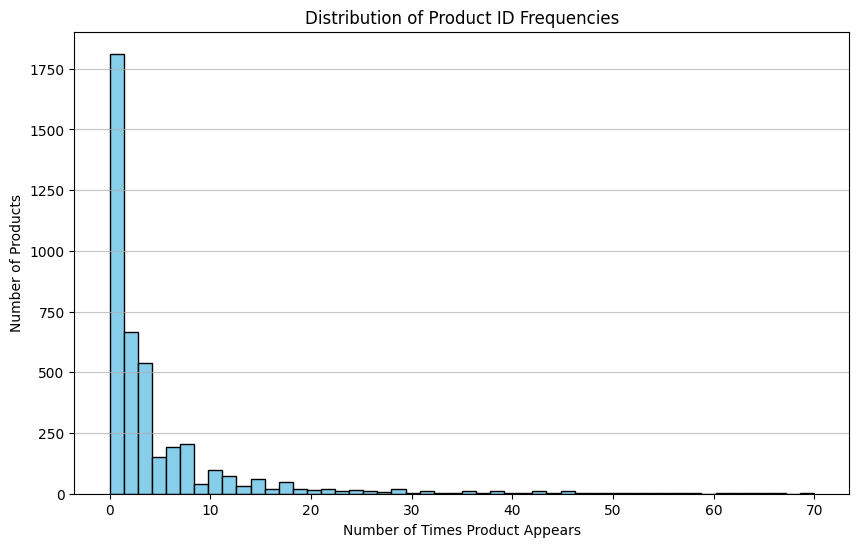

In [10]:
plt.figure(figsize=(10, 6))
plt.hist(product_id_counts.values, bins=50, color='skyblue', edgecolor='black', range=(0, 70))
plt.title('Distribution of Product ID Frequencies')
plt.xlabel('Number of Times Product Appears')
plt.ylabel('Number of Products')
plt.grid(axis='y', alpha=0.75)
plt.show()

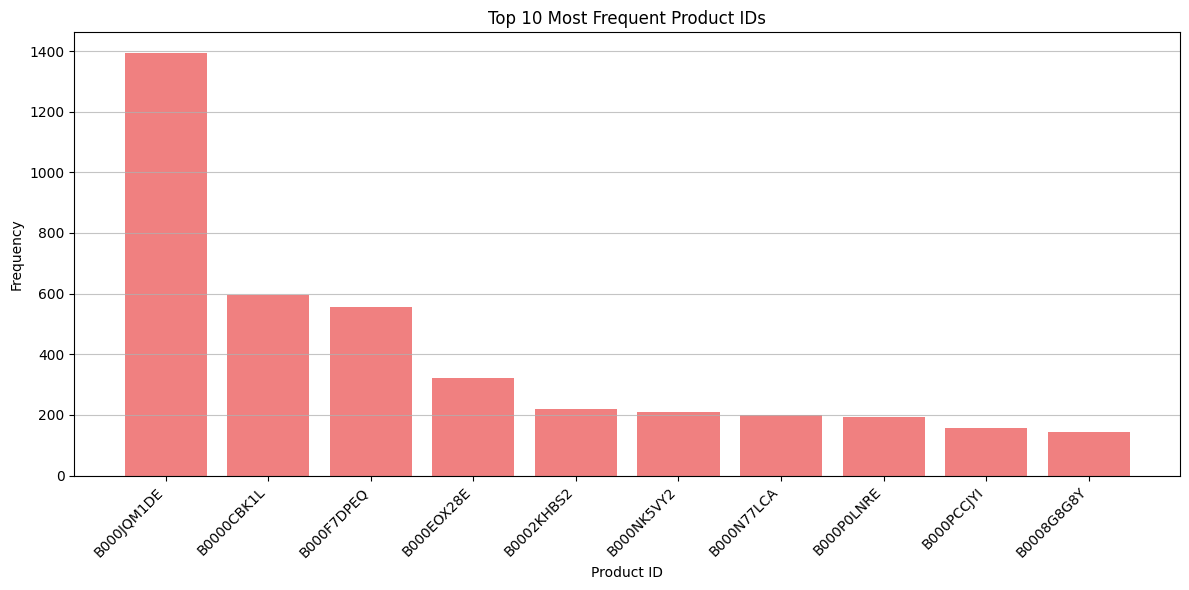

In [11]:
top_10_products = product_id_counts.head(10)

plt.figure(figsize=(12, 6))
plt.bar(top_10_products.index, top_10_products.values, color='lightcoral')
plt.title('Top 10 Most Frequent Product IDs')
plt.xlabel('Product ID')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

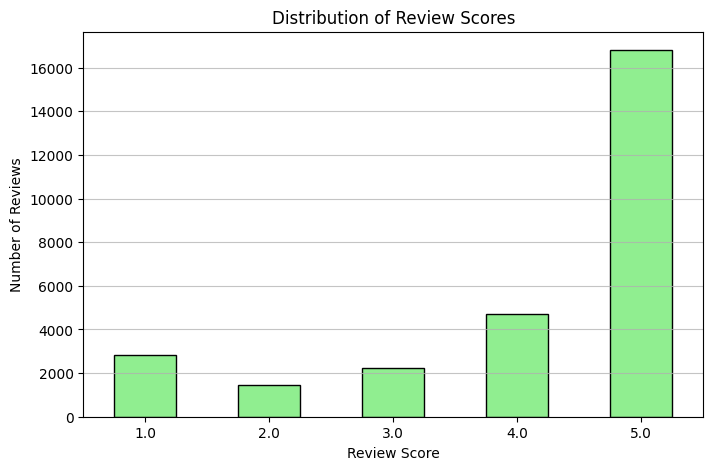

In [12]:
df['score'] = pd.to_numeric(df['score'], errors='coerce')
score_counts = df['score'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
score_counts.plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title('Distribution of Review Scores')
plt.xlabel('Review Score')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.75)
plt.show()

In [13]:
print(df['price'].value_counts())

price
unknown    3887
153.95     1392
199.99      596
85.00       557
74.99       321
           ... 
22.75         1
4.01          1
93.63         1
635.53        1
14.63         1
Name: count, Length: 1731, dtype: int64


In [14]:
df['price'] = pd.to_numeric(df['price'], errors='coerce')
print(f"Number of non-null price values: {df['price'].count()}")
print(f"Number of null price values: {df['price'].isnull().sum()}")

Number of non-null price values: 24093
Number of null price values: 3887


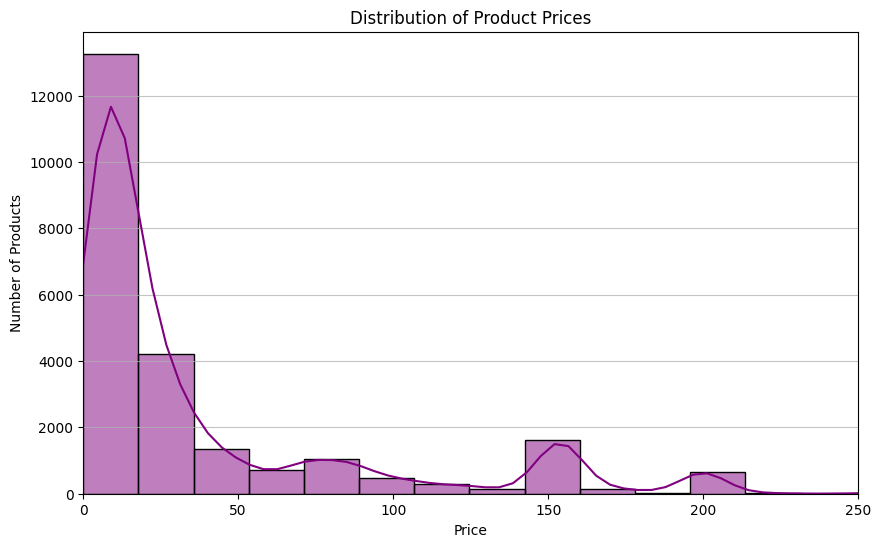

In [15]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'].dropna(), bins=50, kde=True, color='purple')
plt.title('Distribution of Product Prices')
plt.xlabel('Price')
plt.ylabel('Number of Products')
plt.grid(axis='y', alpha=0.75)
plt.xlim(0, 250) # Set x-axis limit
plt.show()

In [16]:
df[['helpful_votes', 'total_votes']] = df['helpfulness'].str.split('/', expand=True)
df['helpful_votes'] = pd.to_numeric(df['helpful_votes'], errors='coerce')
df['total_votes'] = pd.to_numeric(df['total_votes'], errors='coerce')

print("First 5 rows of 'helpful_votes' and 'total_votes' columns:")
print(df[['helpful_votes', 'total_votes']].head())

First 5 rows of 'helpful_votes' and 'total_votes' columns:
   helpful_votes  total_votes
0              2            2
1              0            0
2              1            1
3              0            0
4              0            0


In [17]:
df['helpfulness_ratio'] = df['helpful_votes'] / df['total_votes']
df.loc[df['total_votes'] == 0, 'helpfulness_ratio'] = np.nan

print("First 5 rows with 'helpfulness_ratio' column:")
print(df[['helpful_votes', 'total_votes', 'helpfulness_ratio']].head())

First 5 rows with 'helpfulness_ratio' column:
   helpful_votes  total_votes  helpfulness_ratio
0              2            2                1.0
1              0            0                NaN
2              1            1                1.0
3              0            0                NaN
4              0            0                NaN


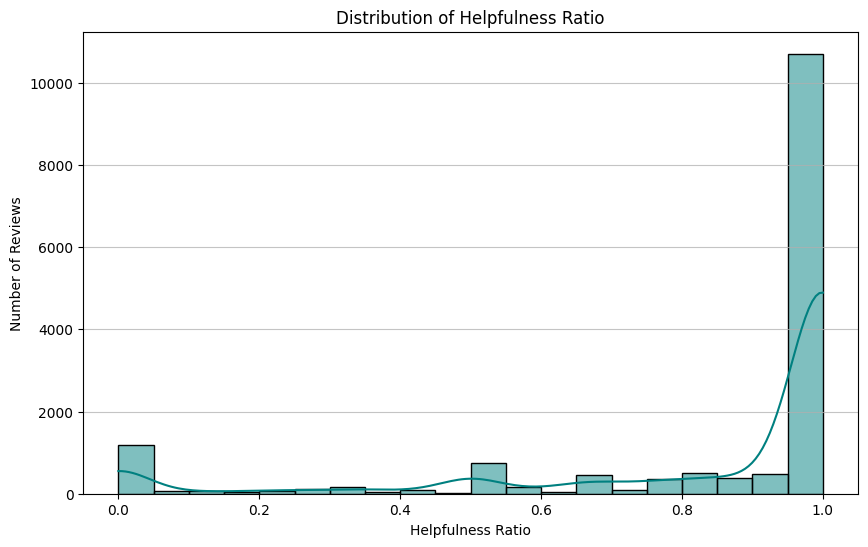

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(df['helpfulness_ratio'].dropna(), bins=20, kde=True, color='teal')
plt.title('Distribution of Helpfulness Ratio')
plt.xlabel('Helpfulness Ratio')
plt.ylabel('Number of Reviews')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [19]:
product_id_to_title = df.drop_duplicates(subset=['productId']).set_index('productId')['title']
print("Product ID to Title Mapping (first few entries):")
print(product_id_to_title.head())

Product ID to Title Mapping (first few entries):
productId
B000GKXY4S                              Crazy Shape Scissor Set
B000140KIW          Fiskars Softouch Multi-Purpose Scissors 10"
B000G6HRZE       Dritz(R) Extra Large Safety Pins-Size 3 65/Pkg
B000140KI2                 Olfa Gridded Cutting Mat 18'' x 24''
B000MAPM7O    Jolee's Boutique Valentine Dimensional Sticker...
Name: title, dtype: object


In [20]:
top_10_product_titles = top_10_products.index.map(product_id_to_title)
print("Titles for Top 10 Most Frequent Products:")
print(top_10_product_titles)

Titles for Top 10 Most Frequent Products:
Index(['Brother CS6000i Feature-Rich Sewing Machine With 60 Built-In Stitches, 7 styles of 1-Step Auto-Size Buttonholes, Quilting Table, and Hard Cover',
       'Brother 1034D 3 or 4 Thread Serger with Easy Lay In Threading with Differential Feed',
       'Brother XL2600I Sew Advance Sew Affordable 25-Stitch Free-Arm Sewing Machine',
       'Brother LS2125i Easy-to-Use, Everyday Sewing Machine with 10 stitches including Blind Hem and Zigzag, and 4-Step Auto Buttonhole',
       'Brother 5300 Universal Sewing Machine Carrying Case',
       'SE Leather Hole Punch Tool, Heavy Duty 2.0mm - 4.5mm',
       'The Sibley Guide To Birds',
       'Westcott Straight Titanium Scissors with New Handle Design, 8-Inch, Two per Pack',
       'SE Jeweler's Loupe - 30X',
       'Sakura 30062 6-Piece Pigma Micron Clam Ink Pen Set, Black'],
      dtype='object', name='productId')


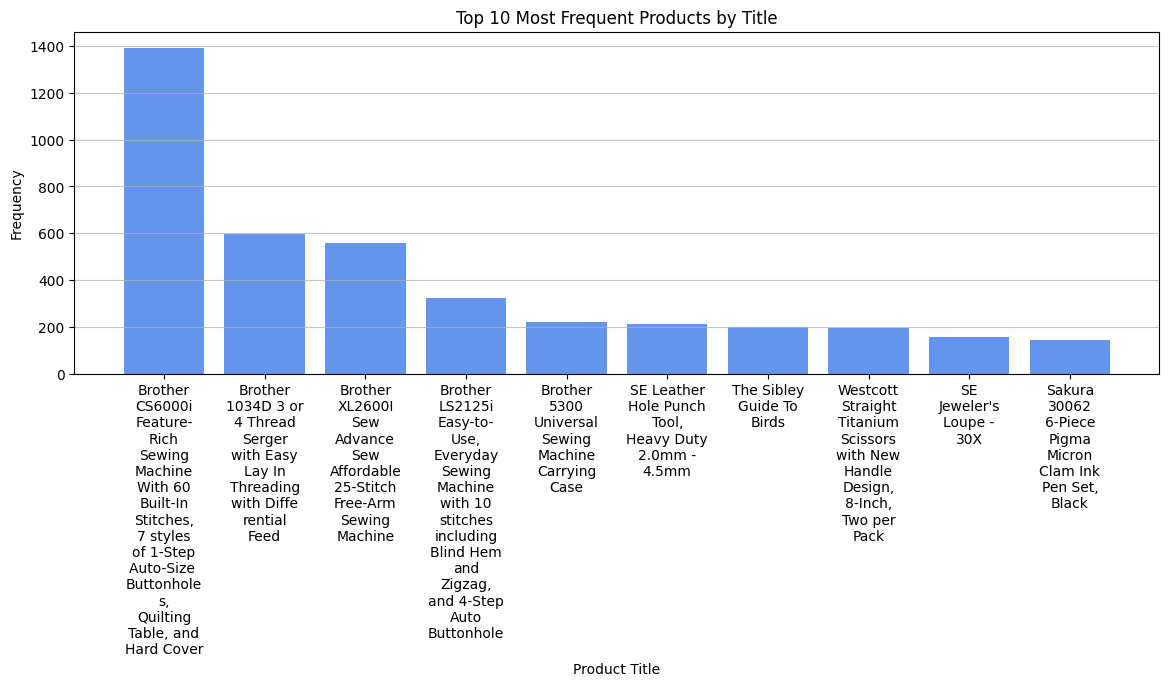

In [21]:
import textwrap

def wrap_title(title, width=10):
    return "\n".join(textwrap.wrap(title, width))

# Re-defining top_10_products and top_10_product_titles to ensure they are available
top_10_products = product_id_counts.head(10)
top_10_product_titles = top_10_products.index.map(product_id_to_title)

wrapped_titles = [wrap_title(title) for title in top_10_product_titles]

plt.figure(figsize=(14, 9)) # Increased figure height to provide more space
plt.bar(wrapped_titles, top_10_products.values, color='cornflowerblue')
plt.title('Top 10 Most Frequent Products by Title')
plt.xlabel('Product Title')
plt.ylabel('Frequency')
plt.xticks(rotation=0, ha='center') # Set rotation to 0 for wrapped labels
plt.grid(axis='y', alpha=0.75)
plt.subplots_adjust(bottom=0.5) # Adjusted bottom margin for multiline labels
plt.show()

# Task
Analyze the 'df' DataFrame to determine the total number of unique users, identify the top 10 users with the most reviews based on the 'userId' and 'profileName' columns, and visualize these top 10 users with a bar chart, finally summarizing the total unique users and listing the top reviewers.

## Calculate Unique Users

### Subtask:
Calculate and display the total number of unique users based on the 'userId' column in the DataFrame.


**Reasoning**:
Calculate the number of unique users in the 'userId' column and display it.



In [22]:
unique_users = df['userId'].nunique()
print(f"Total number of unique users: {unique_users}")

Total number of unique users: 24071


**Reasoning**:
The next step is to identify the top 10 users with the most reviews. I will count the occurrences of each 'userId' to determine the review frequency per user.



In [23]:
user_review_counts = df['userId'].value_counts()
print("User review counts (first 5 entries):\n", user_review_counts.head())

User review counts (first 5 entries):
 userId
unknown           230
A2D1LPEUCTNT8X     39
A22CW0ZHY3NJH8     24
A1HACP80YXJRPP     23
A1AA2CKVYW2MHE     18
Name: count, dtype: int64


**Reasoning**:
Now that the review counts per user have been determined, the next step is to retrieve the top 10 users based on these counts. I will use the `head(10)` method on the `user_review_counts` Series to get the top 10 user IDs and their corresponding review counts. Then, I will merge this information with the original DataFrame to get the `profileName` for these top users, dropping duplicates to ensure each `userId` has only one `profileName` associated with it.



In [24]:
top_10_users_id = user_review_counts.head(10)

# Get the profileName for the top 10 user IDs
top_10_users_info = df[df['userId'].isin(top_10_users_id.index)][['userId', 'profileName']].drop_duplicates()

# Merge review counts with profile names
top_10_reviewers = pd.merge(
    top_10_users_id.rename('review_count'),
    top_10_users_info,
    left_index=True,
    right_on='userId'
).set_index('userId')

print("Top 10 users with the most reviews:")
print(top_10_reviewers)

Top 10 users with the most reviews:
                review_count                 profileName
userId                                                  
unknown                  230                     unknown
A2D1LPEUCTNT8X            39                   Ali Julia
A22CW0ZHY3NJH8            24                      Noname
A1HACP80YXJRPP            23                       Mateo
A1AA2CKVYW2MHE            18                Honest Momma
A24NCF4KFZQHL0            17      Jessica Reid "Jessica"
A1D86BN68B148L            17                          AF
A3FPTGF6TRQGA6            17             Renaissance Man
A1GYEGLX3P2Y7P            17              Shala Kerrigan
A1P01OAMWRJYEA            17  J. Darensbourg "Lady Jane"


**Reasoning**:
To visualize the top 10 users with the most reviews, I will create a bar chart using the `top_10_reviewers` DataFrame. The `profileName` will be on the x-axis, and `review_count` will be on the y-axis, providing a clear representation of review frequency by user.



/tmp/ipython-input-750698432.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_reviewers['profileName'], y=top_10_reviewers['review_count'], palette='viridis')


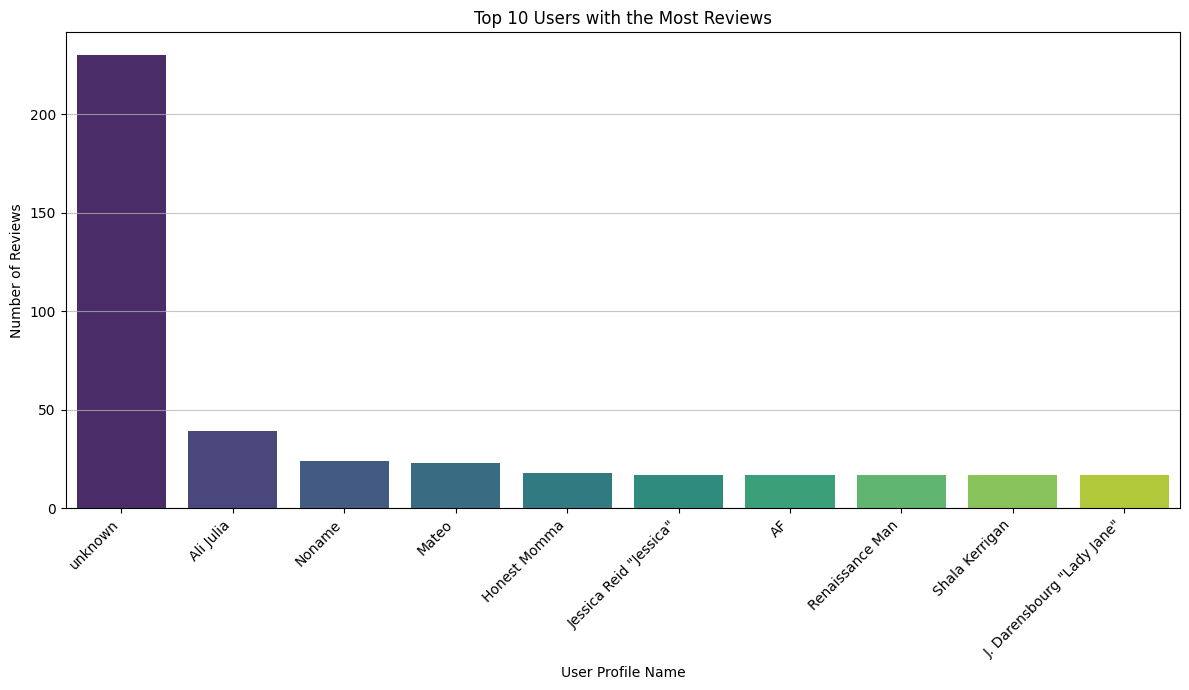

In [25]:
plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_reviewers['profileName'], y=top_10_reviewers['review_count'], palette='viridis')
plt.title('Top 10 Users with the Most Reviews')
plt.xlabel('User Profile Name')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

**Reasoning**:
The previous code generated a `FutureWarning` regarding the use of `palette` without `hue` in `sns.barplot`. To resolve this, I will explicitly set `hue` to the `profileName` column and `legend` to `False` as suggested by the warning.



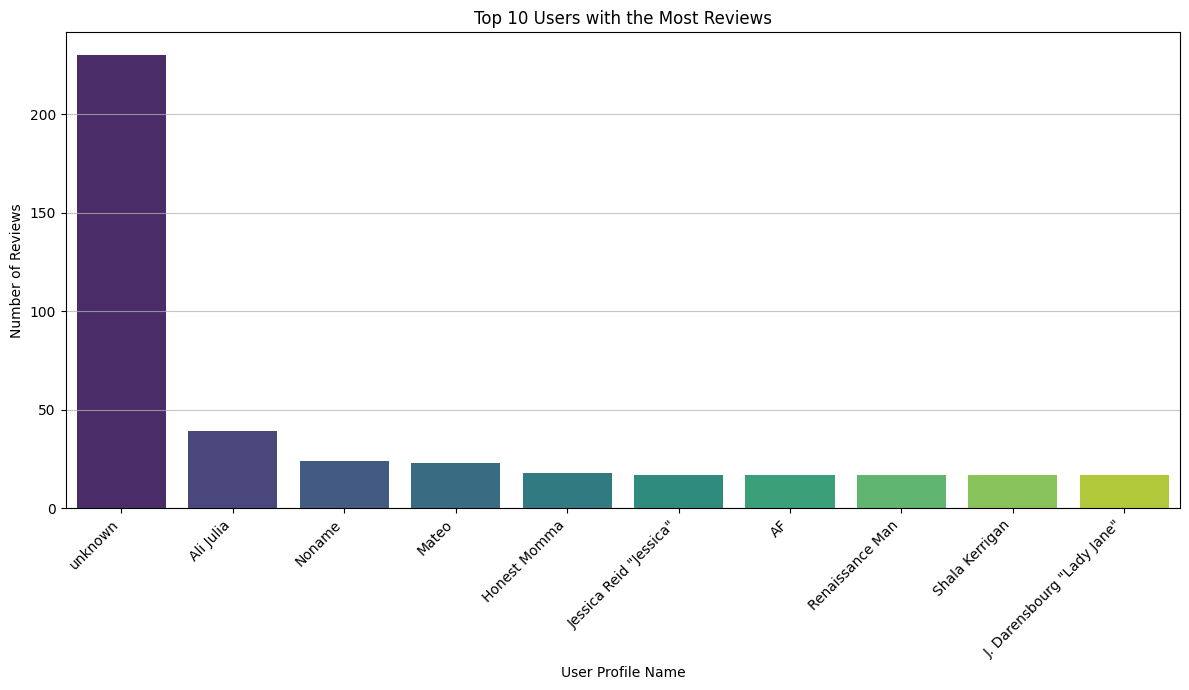

In [26]:
plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_reviewers['profileName'], y=top_10_reviewers['review_count'], hue=top_10_reviewers['profileName'], palette='viridis', legend=False)
plt.title('Top 10 Users with the Most Reviews')
plt.xlabel('User Profile Name')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

In [27]:
df['review_length'] = df['text'].str.len()
print("DataFrame with 'review_length' column (first 5 rows):")
print(df[['text', 'review_length']].head())

DataFrame with 'review_length' column (first 5 rows):
                                                text  review_length
0  I really enjoy these scissors for my inspirati...            298
1  Looked all over in art supply and other stores...            377
2  These are the BEST scissors I have ever owned....            457
3  This Fiskars Scissors are the best i've bougth...            155
4  I finally gave in and bought these after years...            439


In [28]:
average_review_length = df['review_length'].mean()
print(f"The average review length is: {average_review_length:.2f} characters")

The average review length is: 390.83 characters


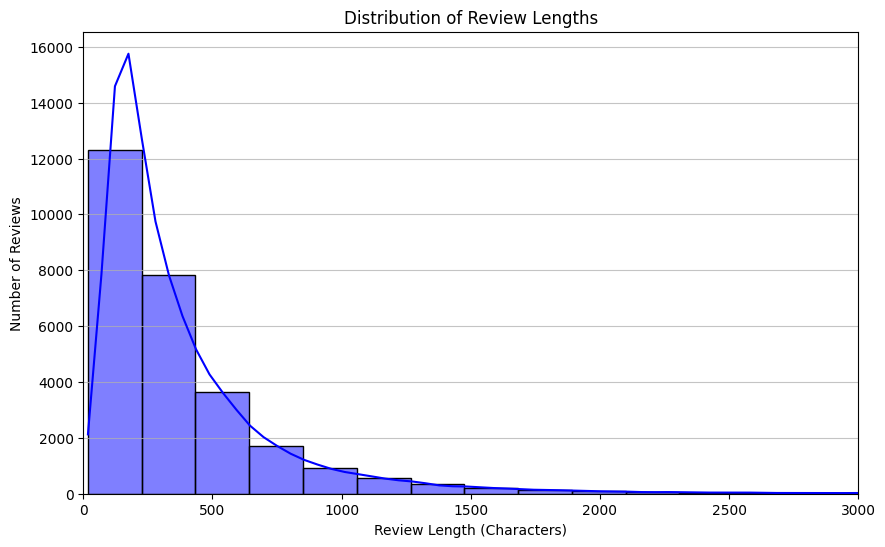

In [30]:
plt.figure(figsize=(10, 6))
sns.histplot(df['review_length'].dropna(), bins=50, kde=True, color='blue')
plt.title('Distribution of Review Lengths')
plt.xlabel('Review Length (Characters)')
plt.ylabel('Number of Reviews')
plt.grid(axis='y', alpha=0.75)
plt.xlim(0, 3000) # Set x-axis limit to 3000
plt.show()

In [2]:
import pandas as pd

predictions_df = pd.read_parquet('/content/predictions.snappy.parquet')
print("Predictions DataFrame loaded successfully:")
predictions_df.head()

Predictions DataFrame loaded successfully:


,userIndex,recommendations
0,0,"[{'itemIndex': 3481, 'rating': 5.4854397773742..."
1,1,"[{'itemIndex': 1650, 'rating': 5.1854233741760..."
2,2,"[{'itemIndex': 3481, 'rating': 6.3812503814697..."
3,3,"[{'itemIndex': 3259, 'rating': 2.3210248947143..."
4,4,"[{'itemIndex': 875, 'rating': 4.99079608917236..."
